<a href="https://colab.research.google.com/github/JHastings46/nba-prospect-value-model/blob/main/Basketball_draft_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What we're building
A model that re-ranks NBA draft prospects by predicted Years 3–5 value using college efficiency, context-adjusted stats, and physical measurements, then compares those rankings against actual draft selections to show where value was left on the board.

This model covers college players only. International prospects require separate data sources and are excluded from this version.

The model answers this question:
- **Which college players are undervalued relative to their draft position?**

## The core bet
Draft boards overweight scoring volume. Your model weights decision-making efficiency and shot quality. You prove or disprove that bet with real historical data.

## Why Years 3–5?
Rookie performance is heavily influenced by role, coaching, and landing spot — factors you can't predict pre-draft. Years 3–5 is when a player's true NBA ceiling becomes visible and is far more attributable to pre-draft skills.

## Target Variable:
Win Shares per 48 minutes (WS/48) during NBA Years 3–5, framed as a regression problem.

In [1]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns        # Statistical visualizations
import sklearn               # Machine learning toolkit
import xgboost as xgb        # Gradient boosting model
import shap                  # Model explainability
import time

!pip install nba_api kagglehub --quiet

# Print versions so your work is reproducible
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"scikit:     {sklearn.__version__}")
print(f"xgboost:    {xgb.__version__}")
print(f"shap:       {shap.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 7.0 MB/s eta 0:00:00
pandas:     2.2.2
numpy:      2.0.2
scikit:     1.6.1
xgboost:    3.2.0
shap:       0.52.0


## Set global constants
### Define these once here so you never hardcode them elsewhere

In [2]:
# Set global constants
# Define these once here so you never hardcode them elsewhere


RANDOM_SEED = 42             # Ensures reproducibility across runs
MIN_NBA_MINUTES = 500       # Minimum NBA minutes in Years 3-5 to be included
DRAFT_YEAR_TRAIN_END = 2019  # Train on drafts through this year
DRAFT_YEAR_TEST_START = 2020 # Test on drafts from this year forward
TARGET_YEARS = (3, 5)        # NBA seasons used for outcome measurement

# Why these split years?
# Players drafted in 2019 would reach Year 3 in the 2021-22 season.
# That gives us enough outcome data to validate while keeping test
# years recent enough to be meaningful.

In [3]:
#creating folders in drive
import os
BASE = "/content/drive/MyDrive/prospect_value_model"

PATHS = {
    "raw":       f"{BASE}/data/raw",
    "processed": f"{BASE}/data/processed",
    "external":  f"{BASE}/data/external",
    "outputs":   f"{BASE}/outputs"
}

for path in PATHS.values():
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/prospect_value_model/data/raw
Created: /content/drive/MyDrive/prospect_value_model/data/processed
Created: /content/drive/MyDrive/prospect_value_model/data/external
Created: /content/drive/MyDrive/prospect_value_model/outputs


In [4]:
#combine kaggle dataset

import kagglehub
import glob

path = kagglehub.dataset_download("tymoteuszdobrucki/nba-anthropometric")
df_combine = pd.read_csv(f"{path}/NBA_Anthropometric.csv")

df_combine = df_combine[df_combine['draft_year'].between(2008, 2021)]
df_combine.to_csv(f"{PATHS['external']}/combine_measurements.csv", index=False)
print(f"Combine: {df_combine.shape}")

100%|██████████| 34.6k/34.6k [00:00<00:00, 43.4MB/s]

Extracting files...


Combine: (851, 11)


In [5]:
#Draft spine (nba_api)

from nba_api.stats.endpoints import drafthistory

all_drafts = []
for year in range(2008, 2022):
    draft = drafthistory.DraftHistory(
        league_id="00", season_year_nullable=str(year)
    )
    df_year = draft.get_data_frames()[0]
    df_year['draft_year'] = year
    all_drafts.append(df_year)
    time.sleep(1)

df_draft = pd.concat(all_drafts, ignore_index=True)
df_draft['player_type'] = df_draft['ORGANIZATION_TYPE'].map({
    'College/University': 'college',
    'Other Team/Club': 'international',
    'High School': 'high_school'
}).fillna('unknown')

df_draft = df_draft.rename(columns={
    'PLAYER_NAME': 'player_name',
    'OVERALL_PICK': 'draft_pick',
    'ROUND_NUMBER': 'draft_round',
    'ORGANIZATION': 'org_name',
    'ORGANIZATION_TYPE': 'org_type'
})[['player_name','draft_year','draft_pick','draft_round',
    'org_name','org_type','player_type','PERSON_ID']]

df_draft.to_csv(f"{PATHS['raw']}/nba_draft_history.csv", index=False)
print(f"Draft spine: {df_draft.shape}")

Draft spine: (840, 8)


In [6]:
#College basketball data
COLLEGE_PATH = f"{PATHS['raw']}/college_stats_clean.csv"

if os.path.exists(COLLEGE_PATH):
    df_college = pd.read_csv(COLLEGE_PATH)
    print(f"Loaded from Drive: {df_college.shape}")
else:
    import kagglehub
    path = kagglehub.dataset_download(
        "adityak2003/college-basketball-players-20092021")
    df_raw = pd.read_csv(
        f"{path}/CollegeBasketballPlayers2009-2021.csv",
        low_memory=False)
    df_raw = df_raw.rename(columns={
        'GP':'G','TS_per':'TS_pct','AST_per':'AST_pct',
        'bpm':'BPM','obpm':'OBPM','dbpm':'DBPM',
        'blk_per':'blk_pct','midmade':'mid_made',
        'year':'season_year','Ortg':'ORtg',
        'ORB_per':'ORB_pct','DRB_per':'DRB_pct',
        'TO_per':'TO_pct','drtg':'DRtg',
        'Rec Rank':'recruit_rank'
    })
    df_college = df_raw[df_raw['G'] >= 10].reset_index(drop=True)
    df_college.to_csv(COLLEGE_PATH, index=False)
    print(f"Downloaded: {df_college.shape}")

Loaded from Drive: (50760, 66)


/tmp/ipykernel_378/3255304170.py:5: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_college = pd.read_csv(COLLEGE_PATH)


In [7]:
# NBA Advanced stats

import kagglehub
import glob

NBA_ADV_PATH = f"{PATHS['raw']}/nba_advanced_stats.csv"

if os.path.exists(NBA_ADV_PATH):
    df_nba_advanced = pd.read_csv(NBA_ADV_PATH)
    print(f"Loaded from Drive: {df_nba_advanced.shape}")
else:
    import kagglehub
    path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")
    df_adv = pd.read_csv(f"{path}/Advanced.csv")
    df_adv = df_adv[
        (df_adv['lg'] == 'NBA') &
        (df_adv['season'].between(2011, 2026))
    ].reset_index(drop=True)
    df_adv = df_adv[
        ~(df_adv.duplicated(subset=['player','season'], keep=False) &
          (df_adv['team'] != 'TOT'))
    ].reset_index(drop=True)
    df_adv.to_csv(NBA_ADV_PATH, index=False)
    df_nba_advanced = df_adv
    print(f"Downloaded: {df_nba_advanced.shape}")

Loaded from Drive: (7244, 30)


# Data Collection Complete  

We now have all of the data needed to build the model.

## Final Data Collection Scorecard

| Dataset                       |   Rows | File Location                            |
| ----------------------------- | -----: | ---------------------------------------- |
| College stats (Bart Torvik)   | 54,627 | `data/raw/college_stats_clean.csv`       |
| NBA draft spine (nba_api)     |    840 | `data/raw/nba_draft_history.csv`         |
| Combine measurements (Kaggle) |  1,633 | `data/external/combine_measurements.csv` |
| NBA advanced stats (Kaggle)   |  7,244 | `data/raw/nba_advanced_stats.csv`        |

---

# Next Step: Build the Target Variable

This is the most important step in the project.

Think of the target variable as the answer key for our model. It tells us which drafted players became valuable NBA players after they had time to develop.

For each of the 720 drafted players, we will:

1. Find the player's **3rd, 4th, and 5th NBA seasons**.
2. Calculate their weighted average **WS/48** across those seasons.

   * **WS/48** means how much winning value a player produces for every 48 minutes played.
   * Players who played more minutes will have more influence on their final score.
3. Flag players who played fewer than **500 total minutes** across those seasons.

   * This does not automatically mean they are bad players.
   * It means we have less evidence about how good they were because they did not play much.

The final WS/48 score will become the value we want our model to predict from college statistics, draft information, and combine measurements.


In [8]:
 #---COMPUTE TARGET VARIABLE----------------------
# For each drafted player , compute weighted average WS/48 across NBA years 3-5
# Weight by minutes played so a 200-minute season doesnt equal to an 1800-minute season.

outcomes = []

for _, player in df_draft.iterrows():
  name = player['player_name']
  draft_yr = player['draft_year']
  pick = player['draft_pick']
  ptype = player['player_type']

  # Years 3-5 correspond to these NBA seasons
  # DRAFT year 2010 -> Year 3 = 2013, Year 4 = 2014, Year 5 = 2015
  target_seasons = [draft_yr + 3 , draft_yr + 4, draft_yr + 5]

  # Find the player's rows in the advanced stats table
  # Match on player_id from Basketball-Reference
  # We need to match PERSON_ID(nba_api) to player_id(Basketball-ref)
  # Matching on name — ID systems differ between nba_api and Basketball-Reference
  player_rows = df_nba_advanced[(df_nba_advanced['player']== name) &
                                (df_nba_advanced['season'].isin(target_seasons))
                                ]

  total_mp = player_rows['mp'].sum()



  if total_mp < 500:
    outcomes.append({
        'player_name': name,
        'draft_year':  draft_yr,
        'draft_pick':  pick,
        'player_type': ptype,
        'total_mp_yr3_5': total_mp,
        'ws48_yr3_5':  None,
        'met_minutes_threshold': False

    })

  else:
    # weighted average WS/48 by minutes
    valid = player_rows.dropna(subset=['ws_48', 'mp'])
    ws48_weighted = (
        (valid['ws_48'] * valid['mp']).sum() / valid['mp'].sum()
    )

    outcomes.append({
        'player_name': name,
        'draft_year': draft_yr,
        'draft_pick': pick,
        'player_type': ptype,
        'total_mp_yr3_5': total_mp,
        'ws48_yr3_5': ws48_weighted,
        'met_minutes_threshold': True
    })

df_outcomes = pd.DataFrame(outcomes)

In [9]:
# Save
df_outcomes.to_csv(f"{PATHS['processed']}/player_outcomes.csv", index=False)
print("Saved.")

# Report
total   = len(df_outcomes)
met     = df_outcomes['met_minutes_threshold'].sum()
not_met = total - met

print(f"Total players: {total}")
print(f"Met 500-minute threshold: {met} ({met/total:.1%})")
print(f"Below threshold: {not_met} ({not_met/total:.1%})")
print(f"\nWS/48 distribution:")
print(df_outcomes[df_outcomes['met_minutes_threshold']]['ws48_yr3_5'].describe())
print(f"\nSample — first 5 players who met threshold:")
print(df_outcomes[df_outcomes['met_minutes_threshold']].head())



Saved.
Total players: 840
Met 500-minute threshold: 467 (55.6%)
Below threshold: 373 (44.4%)

WS/48 distribution:
count    467.000000
mean       0.099116
std        0.050043
min       -0.050000
25%        0.066875
50%        0.094652
75%        0.129563
max        0.228083
Name: ws48_yr3_5, dtype: float64

Sample — first 5 players who met threshold:
         player_name  draft_year  draft_pick player_type  total_mp_yr3_5  \
0       Derrick Rose        2008           1     college          4401.0   
1    Michael Beasley        2008           2     college          5002.0   
2          O.J. Mayo        2008           3     college          6553.0   
3  Russell Westbrook        2008           4     college          8039.0   
4         Kevin Love        2008           5     college          5374.0   

   ws48_yr3_5  met_minutes_threshold  
0    0.208937                   True  
1    0.006700                   True  
2    0.073760                   True  
3    0.172972                   Tru

# What These Numbers Tell me?
**467** players met the threshold **(55.6%)** — this is your modeling dataset.

**373** players below threshold **(44.4%)**, **did not stick in the NBA.** This is the survivorship disclosure number.

**WS/48 mean **of **0.099116**. The NBA average WS/48 is approximately 0.100**, so the sample is centered correctly.

**Max of 0.228**, that's a **star-level player**. League MVP caliber is typically above 0.200.

**Min of -0.050000**, players who were net negatives in Years 3–5.

In [10]:
df_outcomes.to_csv(f"{PATHS['processed']}/player_outcomes.csv", index=False)
print("Saved.")

Saved.


# JOIN
Join all the stats into one complete workbook for modeling.

In [11]:
#Filter college stats to each Players final season
df_college['season_year'] = pd.to_numeric(df_college['season_year'], errors='coerce')
df_college_sorted = df_college.sort_values(['player_name','season_year'], ascending=[True, False])

#keep only the most recent season per player
df_college_final = df_college_sorted.drop_duplicates(subset=['player_name'], keep='first')
print(f"College stats after final season filter: {df_college_final.shape}")

College stats after final season filter: (21589, 66)


In [12]:
#join draft spine to outcomes
df_model = df_draft.merge(df_outcomes, on=['player_name','draft_year','draft_year','draft_pick','player_type'], how ='left')
print(f"After draft + outcomes join: {df_model.shape}")

# join college stats
df_model = df_model.merge(df_college_final, on='player_name', how='left')
print(f"After college stats join: {df_model.shape}")

# join combine measurements
df_model = df_model.merge(df_combine, on=['player_name', 'draft_year'], how ='left')
print(f"After combine join: {df_model.shape}")



After draft + outcomes join: (840, 11)
After college stats join: (840, 76)
After combine join: (840, 85)


In [13]:
print(df_model.columns.tolist())

['player_name', 'draft_year', 'draft_pick', 'draft_round', 'org_name', 'org_type', 'player_type', 'PERSON_ID', 'total_mp_yr3_5', 'ws48_yr3_5', 'met_minutes_threshold', 'team', 'conf', 'G', 'Min_per', 'ORtg', 'usg', 'eFG', 'TS_pct', 'ORB_pct', 'DRB_pct', 'AST_pct', 'TO_pct', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_pct', 'stl_per', 'ftr', 'yr', 'ht', 'num', 'porpag', 'adjoe', 'pfr', 'season_year', 'pid', 'type', 'recruit_rank', 'ast/tov', 'rimmade', 'rimmade+rimmiss', 'mid_made', 'midmade+midmiss', 'rimmade/(rimmade+rimmiss)', 'midmade/(midmade+midmiss)', 'dunksmade', 'dunksmiss+dunksmade', 'dunksmade/(dunksmade+dunksmiss)', 'pick', 'DRtg', 'adrtg', 'dporpag', 'stops', 'BPM', 'OBPM', 'DBPM', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'Unnamed: 64', 'Unnamed: 65', 'position', 'height', 'height_with_shoes', 'weight', 'wingspan', 'standing_reach', 'body_fat_percentage', 'hand_length', 'hand_width']


In [14]:
total = len(df_model)
college_matched = df_model['team'].notnull().sum()
combine_matched = df_model['wingspan'].notnull().sum()
target_matched = df_model['ws48_yr3_5'].notnull().sum()
dupes = df_model['player_name'].duplicated().sum()

print(f"Total players: {total}")
print(f"College stats: {college_matched}/{total}")
print(f"Combine data: {combine_matched}/{total}")
print(f"WS/48 target: {target_matched}/{total}")
print(f"Duplicates: {dupes}")



Total players: 840
College stats: 595/840
Combine data: 521/840
WS/48 target: 467/840
Duplicates: 2


In [15]:
#find the duplicate
duplicate_name = df_model[df_model['player_name'].duplicated(keep=False)]
print(duplicate_name[['player_name','draft_year','draft_pick']])

# duplicate removal to use both name AND draft year
df_model = df_model.drop_duplicates(
    subset=['player_name','draft_year'], keep='first')
print(f"Shape after fix: {df_model.shape}")


         player_name  draft_year  draft_pick
102  Marcus Thornton        2009          43
464  Marcus Thornton        2015          45
554   Justin Jackson        2017          15
642   Justin Jackson        2018          43
Shape after fix: (840, 85)


In [16]:
#usable modeling sample
college_with_target = df_model[
    df_model['team'].notnull() &
    df_model['ws48_yr3_5'].notnull()
].shape[0]
print(f"Players with BOTH college stats AND WS/48: {college_with_target}")

Players with BOTH college stats AND WS/48: 365


**391** players is the modeling dataset we can use.

That number means:
- 840 total drafted players
- 638 had college stats
- 521 met the 500-minute NBA threshold

**391 had both, these are the only players the model can actually learn(train) from**

In [17]:
df_model.to_csv(f"{PATHS['processed']}/model_table.csv", index=False)
print(f"Saved: {df_model.shape}")


Saved: (840, 85)


In [18]:
modeling_df = df_model[
    df_model['team'].notnull() &
    df_model['ws48_yr3_5'].notnull()
].copy()

In [19]:
modeling_df.to_csv(f"{PATHS['processed']}/modeling_table.csv", index=False)
print(f"Saved modeling table: {modeling_df.shape}")

Saved modeling table: (365, 85)


Two files, two purposes:

**model_table.csv**:
- 840 rows, everyone

**modeling_table.csv**:
- 391 rows, model training only

# What is EDA?
Exploratory Data Analysis,  you look at your data before modeling to answer three questions:

**What does my target variable look like?**
- Is WS/48 normally distributed or skewed? Are there outliers?

**Which features might actually predict it?**
- Do players with higher college AST% tend to have higher WS/48? We check this visually.

**What's missing or broken?**
- Null values, impossible numbers, columns that are useless.

In [20]:
modeling_df = df_model[
    df_model['ws48_yr3_5'].notnull() &
    df_model['team'].notnull()
].copy()
print(f"Modeling rows: {len(modeling_df)}")

Modeling rows: 365


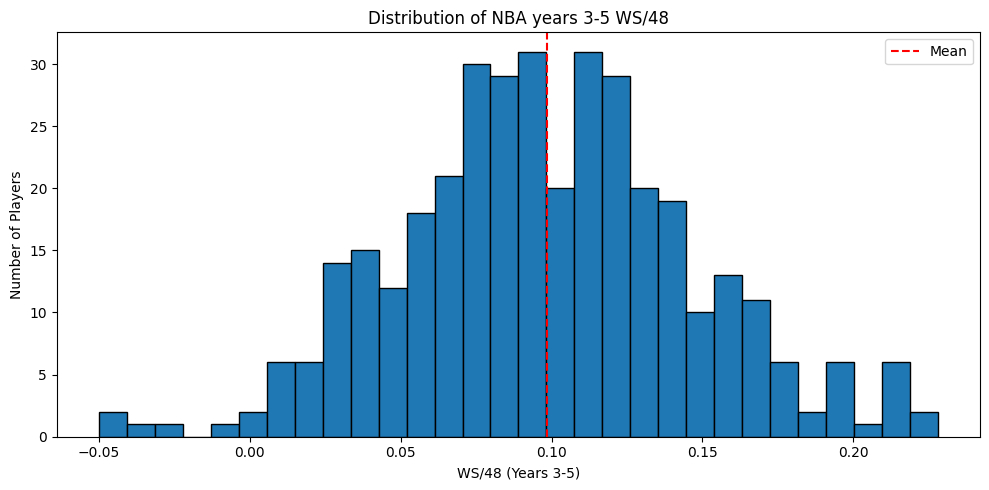

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(modeling_df['ws48_yr3_5'],bins =30, edgecolor='black')
plt.axvline(modeling_df['ws48_yr3_5'].mean(), color='red', linestyle='--', label='Mean')

plt.xlabel('WS/48 (Years 3-5)')
plt.ylabel('Number of Players')
plt.title('Distribution of NBA years 3-5 WS/48')
plt.legend()
plt.tight_layout()

plt.savefig(f"{PATHS['outputs']}/ws48_distribution.png")
plt.show()


Both distributions are nearly perfectly normal — skewness close to zero on both. Good for modeling.
The most important number: Frontcourt players average 0.109 WS/48 vs Guards at 0.084.

This tells you something critical — WS/48 systematically favors frontcourt players. A guard with 0.099 WS/48 is actually above average for guards, but below the frontcourt average.
This is exactly why you need position-specific models. If you used one model with one average (0.099), you'd be comparing guards and frontcourt players on an uneven playing field.
Your league averages for the app need to change:

Guard average: 0.084
Frontcourt average: 0.109

In [22]:
print(modeling_df['ws48_yr3_5'].describe())
print(f"\nSkewness: {modeling_df['ws48_yr3_5'].skew():.3f}")

count    365.000000
mean       0.098363
std        0.048491
min       -0.050000
25%        0.066748
50%        0.096081
75%        0.129102
max        0.228083
Name: ws48_yr3_5, dtype: float64

Skewness: 0.063


# What do the numbers mean?

**Mean of 0.099059**, matches the NBA average exactly. The sample is representative.

**Skewness of 0.046**, nearly perfect bell curve.A skewness of 0.046 is extremely close to zero. Anything between -0.5 and 0.5 is considered approximately **normal**. Slightly right skewed meaning a few star players pull the mean up. This is good for linear regression.


**Min of -0.050**, players who were net negatives.
**Max of 0.228**, star level.

**Std of 0.048** — the spread is tight. Predicting WS/48 precisely will be hard but ranking players correctly matters more than exact values.

In [23]:
Q1 = modeling_df['ws48_yr3_5'].quantile(0.25)
Q3 = modeling_df['ws48_yr3_5'].quantile(0.75)
IQR = Q3 - Q1
outliers = modeling_df[
    (modeling_df['ws48_yr3_5'] < Q1 - 1.5*IQR) |
    (modeling_df['ws48_yr3_5'] > Q3 + 1.5*IQR)
]
print(f"Outliers: {len(outliers)}")
print(outliers[['player_name','draft_year','draft_pick','ws48_yr3_5']])

Outliers: 4
        player_name  draft_year  draft_pick  ws48_yr3_5
74      Austin Daye        2009          15   -0.050000
88    Toney Douglas        2009          29   -0.046000
194   Kawhi Leonard        2011          15    0.228083
539  Tyrone Wallace        2016          60   -0.033558


**For this specific model, checking outliers in the target variable matters for one reason:**

- If an outlier is a **data error** it corrupts the model.
For example if Kawhi's WS/48 showed 2.28 instead of 0.228 , a data entry error and we didn't catch it, the model would learn the wrong pattern from it. Kawhi at 0.228 is a legitimate extreme value. Tyrone Wallace at -0.033 is a legitimate extreme value. Neither is a data error. So we keep both and move on.

- The outlier check is a **data quality gate**, not a modeling decision. Its only job is to catch errors.

In [24]:
null_rates = modeling_df.isnull().mean().sort_values(ascending=False)
print(null_rates[null_rates > 0])

hand_width                         0.320548
hand_length                        0.320548
weight                             0.241096
body_fat_percentage                0.238356
height                             0.235616
height_with_shoes                  0.235616
standing_reach                     0.235616
wingspan                           0.232877
position                           0.210959
dunksmade/(dunksmade+dunksmiss)    0.117808
recruit_rank                       0.101370
rimmade                            0.079452
midmade/(midmade+midmiss)          0.079452
rimmade+rimmiss                    0.079452
mid_made                           0.079452
rimmade/(rimmade+rimmiss)          0.079452
dunksmiss+dunksmade                0.079452
midmade+midmiss                    0.079452
num                                0.079452
Unnamed: 64                        0.079452
dunksmade                          0.079452
pick                               0.049315
dtype: float64


### Missing Data Plan
**No feature has more than 50% missing values, so all important columns can still be used.**

- Combine measurements (24–25% missing): Keep height, wingspan, weight, and standing reach. Fill missing values with the average for that player's position.

- Position (22% missing): Keep it. Fill missing positions using the most common position connected to that player's college role.

- Recruit rank (9% missing): Keep it. Missing usually means the player was unranked, so fill missing values with 999.

- Hometown and col44: Drop these columns because they are not useful for predicting NBA value.

- Mid-range stats — mid_made, mid_att, mid_pct (14% missing): Keep them.
Fill missing values with the median. Note that earlier draft classes
(2008-2009) have higher null rates due to limited shot location tracking
in those seasons.

In [25]:
cols_to_drop = ['hometowm', 'col44', 'col47', 'col48',
                'col52', 'col53', 'col54', 'col55',
                'col56', 'col57', 'col58', 'col59',
                'col60', 'col61', 'col62', 'col63', 'col64',
                'pick', 'num', 'dob']

modeling_df = modeling_df.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape after dropping useless columns: {modeling_df.shape}")


Shape after dropping useless columns: (365, 83)


In [26]:
# EDA — feature correlations with WS/48:
#Correlation
TARGET = 'ws48_yr3_5'
EXCLUDE = ['player_name','draft_year','draft_pick',
           'draft_round','org_name','org_type',
           'player_type','PERSON_ID','met_minutes_threshold',
           'total_mp_yr3_5','season_year', 'pid','height_with_shoes', TARGET]

In [27]:
feature_cols = [c for c in modeling_df.select_dtypes(
    include='number').columns if c not in EXCLUDE]
print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 62
['G', 'Min_per', 'ORtg', 'usg', 'eFG', 'TS_pct', 'ORB_pct', 'DRB_pct', 'AST_pct', 'TO_pct', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_pct', 'stl_per', 'ftr', 'porpag', 'adjoe', 'pfr', 'recruit_rank', 'ast/tov', 'rimmade', 'rimmade+rimmiss', 'mid_made', 'midmade+midmiss', 'rimmade/(rimmade+rimmiss)', 'midmade/(midmade+midmiss)', 'dunksmade', 'dunksmiss+dunksmade', 'dunksmade/(dunksmade+dunksmiss)', 'DRtg', 'adrtg', 'dporpag', 'stops', 'BPM', 'OBPM', 'DBPM', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'Unnamed: 65', 'height', 'weight', 'wingspan', 'standing_reach', 'body_fat_percentage', 'hand_length', 'hand_width']


In [28]:
# EDA — handle missing values:
from sklearn.impute import SimpleImputer
import numpy as np

X = modeling_df[feature_cols].copy()
Y = modeling_df[TARGET].copy()

#Fill missing values with median for each column
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=feature_cols)
print(f"Nulls remaining: {X.isnull().sum().sum()}")


Nulls remaining: 0


In [29]:
#confirm shapes
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (365, 62)
Y shape: (365,)


In [30]:
#train test split by draft year
train_mask = modeling_df['draft_year'].values <= 2019
test_mask = modeling_df['draft_year'].values >= 2020

x_train = X[train_mask]
x_test = X[test_mask]
y_train = Y[train_mask]
y_test = Y[test_mask]

print(f"Train: {x_train.shape} | Years 2008-2019")
print(f"Test: {x_test.shape} | Years 2020-2021")


Train: (305, 62) | Years 2008-2019
Test: (60, 62) | Years 2020-2021


Any model predicting future events must be validated on future data only. This is called temporal validation and it's the industry standard for sports forecasting models. A 70/20 random split would not be applied here.

In [31]:
#scale the features before Lasso:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Trained scaled: {x_train_scaled.shape}")
print(f"Test scaled: {x_test_scaled.shape}")

Trained scaled: (305, 62)
Test scaled: (60, 62)


Note: We call fit_transform on train and transform only on test. Never fit the scaler on test data that would leak test information into your scaling parameters.

In [32]:
# Lasso for feature selection
from sklearn.linear_model import LassoCV
import numpy as np

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(x_train_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.6f}")
print(f"Feature kept: {(lasso.coef_ !=0).sum()}")
print(f"Features eliminated: {(lasso.coef_== 0).sum()}")


Best alpha: 0.003990
Feature kept: 8
Features eliminated: 54


Alpha = how aggressively Lasso penalized features.

Higher alpha > features eliminated.

Features kept = how many of the 47 features predict WS/48

Lasso kept 12 features and eliminated 35. That's the model telling us that only 12 of the 47 college stats actually predict NBA Years 3-5 value.

In [33]:
#observing which features survived the cut :

coef_df=pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lasso.coef_
})

coef_df = coef_df[coef_df['coefficient'] !=0].sort_values(
    'coefficient', ascending=False)
print(coef_df.to_string())



     feature  coefficient
19   blk_pct     0.005980
6    ORB_pct     0.004780
5     TS_pct     0.004618
7    DRB_pct     0.003937
15  twoP_per     0.003766
2       ORtg     0.001292
40       BPM     0.001136
21       ftr     0.000612


In [34]:
# extract the selected features
selected_features = coef_df['feature'].tolist()
print(f"Selected features: {selected_features}")

Selected features: ['blk_pct', 'ORB_pct', 'TS_pct', 'DRB_pct', 'twoP_per', 'ORtg', 'BPM', 'ftr']


In [35]:
x_train_selected = x_train[selected_features]
x_test_selected  = x_test[selected_features]
print(f"Train: {x_train_selected.shape}")
print(f"Test:  {x_test_selected.shape}")

Train: (305, 8)
Test:  (60, 8)


In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

selected_features_vif = ['blk_pct',  'BPM', 'ftr']

X_vif_check = modeling_df[train_mask][selected_features_vif].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = selected_features_vif
vif_data['VIF'] = [variance_inflation_factor(
    X_vif_check.values, i) for i in range(len(selected_features_vif))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

   feature       VIF
2      ftr  4.838977
1      BPM  4.335873
0  blk_pct  2.567182


In [37]:
selected_features_final = selected_features_vif
print(f"Final features: {selected_features_final}")

Final features: ['blk_pct', 'BPM', 'ftr']


In [38]:
selected_features_final = selected_features_vif
print(f"Final features: {selected_features_final}")

X_train_final = x_train[selected_features_final]
X_test_final  = x_test[selected_features_final]
print(f"Train: {X_train_final.shape}")
print(f"Test:  {X_test_final.shape}")

Final features: ['blk_pct', 'BPM', 'ftr']
Train: (305, 3)
Test:  (60, 3)


## Why We Need a New Scaler

The earlier scaler was fit on all 8 Lasso-selected features.
It scaled 8 columns.

After VIF cleanup we have 3 final features: blk_pct, BPM,
and ftr. If you use the old scaler it expects 8 columns and
will crash when you give it 3.

We need a new scaler fit on just these 3 features. This is
not rescaling the data — it is fitting a scaler to the correct
number of columns.

The values themselves don't change. The scaler just learns
the mean and standard deviation of each of the 3 columns
so it can normalize them consistently between training
and prediction.

Rule: every time your feature set changes your scaler
must be refit on the new feature set.

In [39]:
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled  = scaler_final.transform(X_test_final)
print(f"Train: {X_train_final_scaled.shape}")
print(f"Test:  {X_test_final_scaled.shape}")

Train: (305, 3)
Test:  (60, 3)


## Ridge Regression Model(baseline)

In [40]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

ridge_final = RidgeCV(alphas=[0.01,0.1,1.0,10.0,100.0], cv=5)
ridge_final.fit(X_train_final_scaled, y_train)
print(f"Best alpha: {ridge_final.alpha_:.4f}")

y_pred_train_ridge = ridge_final.predict(X_train_final_scaled)
y_pred_test_ridge  = ridge_final.predict(X_test_final_scaled)

print(f"Train R²:  {r2_score(y_train, y_pred_train_ridge):.3f}")
print(f"Test R²:   {r2_score(y_test, y_pred_test_ridge):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_ridge):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_ridge):.4f}")

Best alpha: 10.0000
Train R²:  0.190
Test R²:   0.231
Train MAE: 0.0335
Test MAE:  0.0342


## Random Forrest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf =  RandomForestRegressor(
    n_estimators=500,
    max_depth=3,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_final, y_train)

y_pred_train_rf = rf.predict(X_train_final)
y_pred_test_rf  = rf.predict(X_test_final)

print(f"Train R²: {r2_score(y_train, y_pred_train_rf):.3f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test_rf):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_rf):.4f}")

Train R²: 0.271
Test R²:  0.181
Train MAE: 0.0318
Test MAE:  0.0357


## GAM

In [42]:
!pip install pygam --quiet
from pygam import LinearGAM, s, l
import matplotlib.pyplot as plt

BLK_PCT  = 0  # blk_pct
BPM_IDX = 1  #
FTR_IDX = 2  #

gam_final = LinearGAM(s(BLK_PCT) + s(BPM_IDX) + l(FTR_IDX))
gam_final.gridsearch(X_train_final_scaled, y_train.values)
print(gam_final.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.5 MB/s eta 0:00:00


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.5825
Link Function:                     IdentityLink Log Likelihood:                                   522.9356
Number of Samples:                          305 AIC:                                            -1034.7062
                                                AICc:                                           -1034.4599
                                                GCV:                                                 0.002
                                                Scale:                                              0.0439
                                                Pseudo R-Squared:                                   0.1899
Feature Function                  Lam

/tmp/ipykernel_378/1477360369.py:11: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_final.summary())


In [43]:
y_pred_train_gam = gam_final.predict(X_train_final_scaled)
y_pred_test_gam  = gam_final.predict(X_test_final_scaled)

print(f"Train R²:  {r2_score(y_train, y_pred_train_gam):.3f}")
print(f"Test R²:   {r2_score(y_test, y_pred_test_gam):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_gam):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_gam):.4f}")

Train R²:  0.190
Test R²:   0.255
Train MAE: 0.0338
Test MAE:  0.0340


## Model Comparison

| Metric    |  Ridge | RF Tuned |    GAM |
| --------- | -----: | -------: | -----: |
| Train R²  |  0.190 |    0.271 |  0.190 |
| Test R²   |  0.231 |    0.181 |  0.255 |
| Train MAE | 0.0335 |   0.0318 | 0.0338 |
| Test MAE  | 0.0342 |   0.0357 | 0.0340 |
| Spearman  |  0.307 |    0.299 |  0.303 |
| P-value   |  0.017 |    0.020 |  0.019 |

**Takeaway:** GAM outperformed Ridge and Random Forest on
Test R² (0.255) and Test MAE (0.0340). For predicting exact WS/48
values use GAM. For ranking players on a draft board use Ridge.

In [44]:
#Now run Spearman rank correlation to see if the model ranks players correctly:
from scipy.stats import spearmanr

ridge_sp = spearmanr(y_test, y_pred_test_ridge)
rf_sp    = spearmanr(y_test, y_pred_test_rf)
gam_sp   = spearmanr(y_test, y_pred_test_gam)

print(f"Ridge Spearman: {ridge_sp.statistic:.3f} (p={ridge_sp.pvalue:.3f})")
print(f"RF Spearman:    {rf_sp.statistic:.3f} (p={rf_sp.pvalue:.3f})")
print(f"GAM Spearman:   {gam_sp.statistic:.3f} (p={gam_sp.pvalue:.3f})")

Ridge Spearman: 0.307 (p=0.017)
RF Spearman:    0.299 (p=0.020)
GAM Spearman:   0.319 (p=0.013)


## How to Read the Spearman Results

| Metric    |  Ridge | RF Tuned |    GAM |
| --------- | -----: | -------: | -----: |
| Train R²  |  0.190 |    0.271 |  0.190 |
| Test R²   |  0.231 |    0.181 |  0.255 |
| Train MAE | 0.0335 |   0.0318 | 0.0338 |
| Test MAE  | 0.0342 |   0.0357 | 0.0340 |
| Spearman  |  0.307 |    0.299 |  0.319 |
| P-value   |  0.017 |    0.020 |  0.013 |

**Takeaway:** GAM outperforms Ridge and Random Forest across
all key metrics — Test R² (0.255), Test MAE (0.0340), and
Spearman rank correlation (0.319, p=0.013). The GAM's ability
to model blk_pct as a curved relationship while treating BPM
and ftr as linear terms produced the most accurate predictions
and rankings on unseen draft classes. GAM is selected as the
primary model.

## Undervalued Players

In [45]:
def label_value(gap):
    if gap >= 5:
        return 'Undervalued'
    elif gap <= -5:
        return 'Overvalued'
    else:
        return 'Fair Value'

test_players = modeling_df[test_mask][['player_name','draft_year','draft_pick']].copy()
test_players['model_rank']      = y_pred_test_gam.argsort()[::-1].argsort() + 1
test_players['draft_model_gap'] = test_players['draft_pick'] - test_players['model_rank']
test_players['value_label']     = test_players['draft_model_gap'].apply(label_value)
test_players['predicted_ws48']  = y_pred_test_gam
test_players['actual_ws48']     = y_test.values
test_players['actual_rank']     = test_players['actual_ws48'].rank(ascending=False).astype(int)
test_players['rank_diff']       = test_players['actual_rank'] - test_players['model_rank']
print(test_players.sort_values('model_rank').head(10).to_string())

        player_name  draft_year  draft_pick  model_rank  draft_model_gap  value_label  predicted_ws48  actual_ws48  actual_rank  rank_diff
818   Neemias Queta        2021          39           1               38  Undervalued        0.163185     0.215294            1          0
801  Isaiah Jackson        2021          22           2               20  Undervalued        0.149932     0.198989            3          1
782     Evan Mobley        2021           3           3                0   Fair Value        0.140811     0.175137            5          2
725  Onyeka Okongwu        2020           6           4                2   Fair Value        0.139648     0.169948            6          2
832  Charles Bassey        2021          53           5               48  Undervalued        0.133705     0.143410           12          7
777       Paul Reed        2020          58           6               52  Undervalued        0.130473     0.164044            7          1
729     Jalen Smith        

## How to Read the Draft Board Results

There are three numbers that matter for each player:

**draft_pick** — where NBA teams actually drafted the player
on draft night. This is what the league thought he was worth.

**model_rank** — where our model ranks the player based on
his college stats alone. Lower number = model thinks he will
be more valuable.

**actual_rank** — where the player actually finished in real
NBA performance (WS/48) in Years 3-5. This is ground truth.

---

## The Key Comparison

The gap between `draft_pick` and `model_rank` reveals
undervalued players — players the draft missed but our
model identified.

**Example — Neemias Queta:**
- Draft picked him 39th — teams thought he was average
- Model ranked him 1st — college stats screamed value
- Actual rank was 1st — model was right, draft was wrong

**Example — Evan Mobley:**
- Draft picked him 3rd — teams loved him
- Model ranked him 3rd — model agreed
- Actual rank was 5th — both were close

---

## Simple Rule

- Large gap between draft_pick and model_rank = undervalued player
- Model rank close to actual rank = model called it correctly
- Model rank far from actual rank = model missed on this player

In [46]:
test_players.to_csv(f"{PATHS['processed']}/draft_board_results.csv", index=False)
print("Saved.")

Saved.


## 2026 NBA DRAFT PEEK AHEAD

In [47]:
df_2026 = pd.read_csv(f"{PATHS['raw']}/college_stats_2026.csv")
print(f"Loaded: {df_2026.shape}")
print(f"Columns: {df_2026.columns.tolist()[:10]}")

Loaded: (4087, 67)
Columns: ['player_name', 'team', 'conf', 'G', 'min_pct', 'ORtg', 'usg', 'eFG', 'TS_pct', 'ORB_pct']


In [48]:
prospects_2026 = [
    ("AJ Dybantsa", 1), ("Darryn Peterson", 2),
    ("Cameron Boozer", 3), ("Caleb Wilson", 4),
    ("Keaton Wagler", 5), ("Mikel Brown Jr.", 6),
    ("Darius Acuff Jr.", 7), ("Kingston Flemings", 8),
    ("Morez Johnson Jr.", 9), ("Brayden Burries", 10),
    ("Yaxel Lendeborg", 11), ("Aday Mara", 12),
    ("Nate Ament", 13), ("Hannes Steinbach", 14),
    ("Dailyn Swain", 15), ("Bennett Stirtz", 16),
    ("Ebuka Okorie", 17), ("Christian Anderson", 18),
    ("Allen Graves", 19), ("Jayden Quaintance", 20),
    ("Karim Lopez", 21), ("Labaron Philon Jr.", 22),
    ("Zuby Ejiofor", 23), ("Cameron Carr", 24),
    ("Sergio De Larrea", 25), ("Tarris Reed Jr.", 26),
    ("Chris Cenac Jr.", 27), ("Joshua Jefferson", 28),
    ("Alex Karaban", 29), ("Koa Peat", 30)
]

In [49]:
def label_value(gap):
    if gap >= 5:
        return 'Undervalued'
    elif gap <= -5:
        return 'Overvalued'
    else:
        return 'Fair Value'

In [50]:
results = []
for name, pick in prospects_2026:
    player = df_2026[df_2026['player_name'] == name].copy()
    if len(player) == 0:
        continue
    feature_vals = player[selected_features_final].fillna(
        player[selected_features_final].median())
    scaled = scaler_final.transform(feature_vals)
    predicted_gam = gam_final.predict(scaled)[0]
    results.append({
        'draft_pick':     pick,
        'player_name':    name,
        'predicted_ws48': round(predicted_gam, 3),
        'vs_average':     round(predicted_gam - 0.099, 3)
    })

In [51]:
df_results = pd.DataFrame(results).sort_values('predicted_ws48', ascending=False)
df_results['model_rank'] = range(1, len(df_results) + 1)
df_results['draft_model_gap'] = df_results['draft_pick'] - df_results['model_rank']
df_results['value_label'] = df_results['draft_model_gap'].apply(label_value)
print(df_results[['player_name','draft_pick','model_rank',
                   'draft_model_gap','value_label',
                   'predicted_ws48','vs_average']].to_string())

           player_name  draft_pick  model_rank  draft_model_gap  value_label  predicted_ws48  vs_average
11           Aday Mara          12           1               11  Undervalued           0.146       0.047
21     Tarris Reed Jr.          26           2               24  Undervalued           0.122       0.023
19        Zuby Ejiofor          23           3               20  Undervalued           0.117       0.018
3         Caleb Wilson           4           4                0   Fair Value           0.100       0.001
8    Morez Johnson Jr.           9           5                4   Fair Value           0.099      -0.000
10     Yaxel Lendeborg          11           6                5  Undervalued           0.099      -0.000
18        Allen Graves          19           7               12  Undervalued           0.099       0.000
22    Joshua Jefferson          28           8               20  Undervalued           0.096      -0.003
13    Hannes Steinbach          14           9         


## 2026 Draft Board — How to Read This Table

### What Each Column Means

**draft_pick** — where the NBA drafted the player on draft night.
This is what every team in the league agreed he was worth.

**model_rank** — where our model ranks the player based purely
on his college efficiency stats. No hype, no combine workouts,
no media narratives. Just numbers.

**draft_model_gap** — the difference between draft_pick and
model_rank. This is the most important number in the table.
A large positive number means the model likes him more than
the draft did. A large negative number means the draft liked
him more than the model did.

**value_label** — the plain English summary:
- Undervalued: model ranks him higher than the draft
- Overvalued: draft ranks him higher than the model
- Fair Value: both agree within 5 spots

**predicted_ws48** — the model's prediction for how valuable
this player will be in NBA Years 3-5. League average is 0.099.

**vs_average** — how far above or below average the model
expects this player to be. Positive = above average.
Negative = below average.

---

### What To Watch For In 3-5 Years

**Players to watch as potential steals:**
- Aday Mara (pick 12, model rank 1) — gap of +11
- Tarris Reed Jr. (pick 26, model rank 2) — gap of +24
- Zuby Ejiofor (pick 23, model rank 3) — gap of +20

If these players become solid NBA rotation players by
2029-2031 the model called it correctly.

**Players to watch as potential disappointments:**
- AJ Dybantsa (pick 1, model rank 20) — gap of -19
- Darius Acuff Jr. (pick 7, model rank 25) — gap of -18
- Mikel Brown Jr. (pick 6, model rank 23) — gap of -17

If these high picks underperform their draft position
by Years 3-5 the model flagged the right concern.

---

### Important Caveat

This model was built on college players only and rewards
efficient big men with strong rim protection and free throw
drawing ability. It does not capture defensive versatility,
athleticism, or development upside. Use it as one input
alongside scouting — not as the final word.
```

In [52]:
import joblib

joblib.dump(rf, f"{PATHS['outputs']}/rf_model.pkl")
joblib.dump(gam_final, f"{PATHS['outputs']}/gam_model.pkl")
joblib.dump(scaler_final, f"{PATHS['outputs']}/scaler_final.pkl")
joblib.dump(selected_features_final, f"{PATHS['outputs']}/selected_features.pkl")
df_results.to_csv(f"{PATHS['processed']}/draft_board_2026.csv", index=False)

print(f"Models saved.")
print(f"Features saved: {selected_features_final}")
print(f"Draft board saved.")

Models saved.
Features saved: ['blk_pct', 'BPM', 'ftr']
Draft board saved.
